In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report,precision_score, recall_score, f1_score,roc_auc_score,precision_recall_curve
from sklearn.ensemble import IsolationForest,RandomForestClassifier
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from xgboost import XGBClassifier
from datetime import datetime
import uuid

In [9]:
Fraud_detection_df = pd.read_csv("credit_card_fraud_10k.csv")

In [10]:
Fraud_detection_df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [11]:
Fraud_detection_df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [12]:
Fraud_detection_df.shape

(10000, 10)

In [13]:
Fraud_detection_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [14]:
Fraud_detection_df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [15]:
Fraud_detection_df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


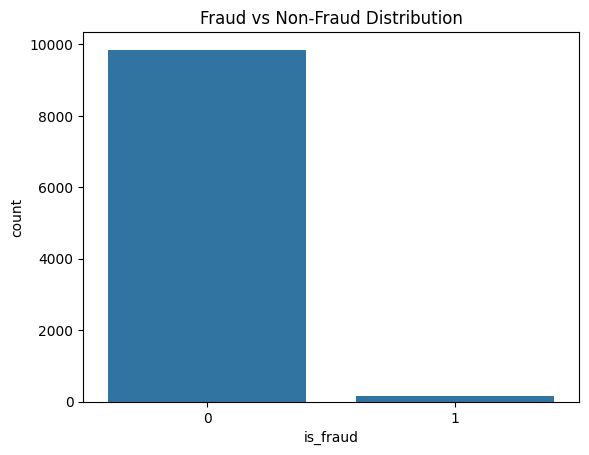

In [16]:
sns.countplot(x='is_fraud', data=Fraud_detection_df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


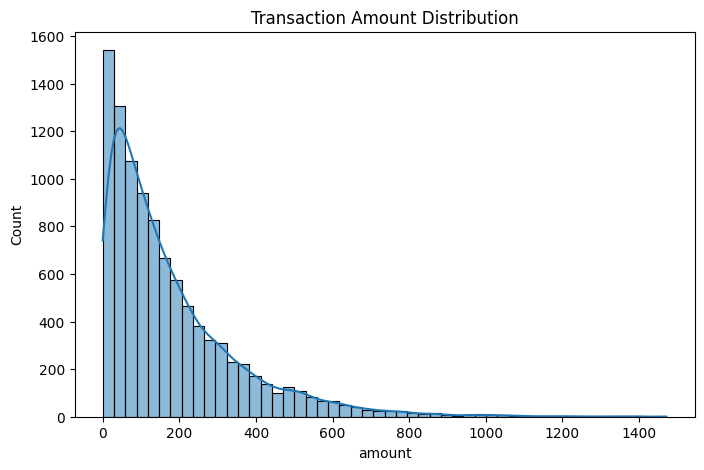

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(Fraud_detection_df['amount'], bins=50,kde=True)
plt.title("Transaction Amount Distribution")
plt.show()


C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


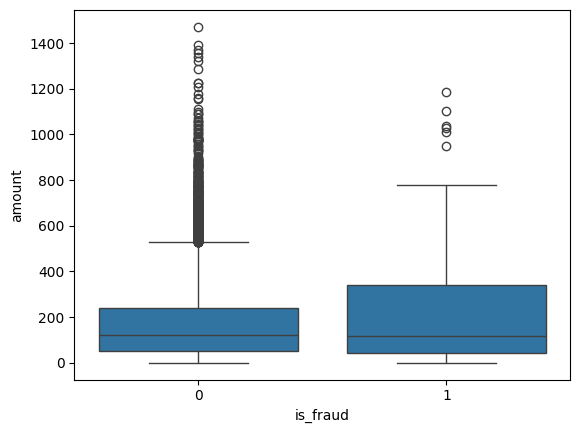

In [18]:
sns.boxplot(x='is_fraud', y='amount', data=Fraud_detection_df)
plt.show()

In [19]:
#The boxplot shows that transaction amount distributions for fraudulent and non-fraudulent transactions overlap significantly.
#While fraudulent transactions exhibit slightly higher variability, the median transaction amounts are comparable across both classes. 
#This suggests that transaction amount alone is insufficient to distinguish fraud.

In [20]:
 # Most transactions are small (from histogram)
 # Fraud median is similar to normal
 # Fraud amount is more spread out
 # High amounts exist in both classes

C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this wa

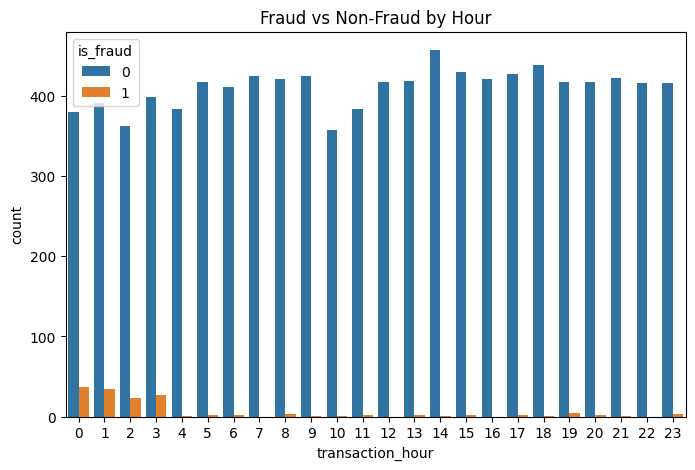

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=Fraud_detection_df, x='transaction_hour', hue='is_fraud')
plt.title("Fraud vs Non-Fraud by Hour")
plt.show()


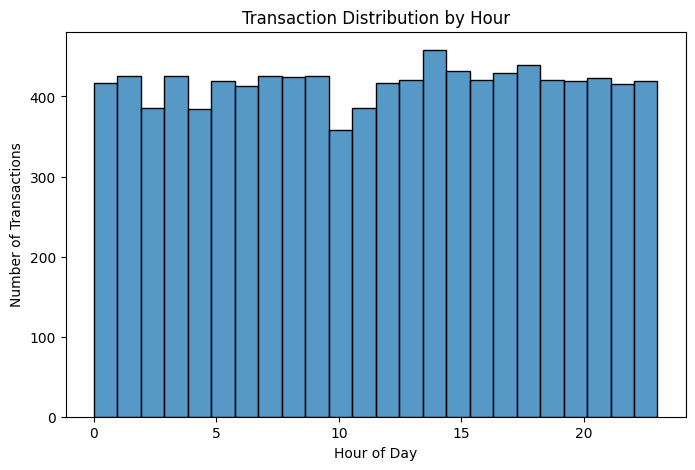

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=Fraud_detection_df, x='transaction_hour', bins=24, kde=False)
plt.title("Transaction Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()


C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='is_fraud', ylabel='velocity_last_24h'>

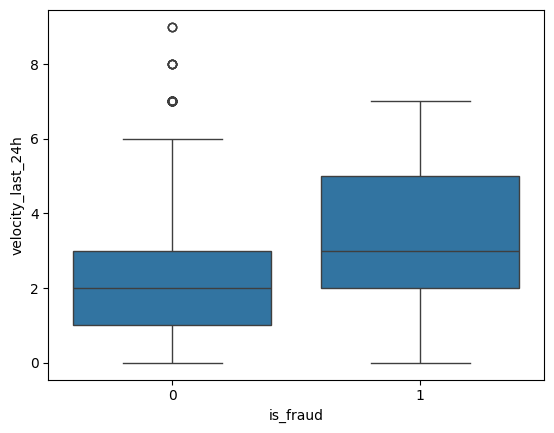

In [23]:
sns.boxplot(x='is_fraud', y='velocity_last_24h', data=Fraud_detection_df)


C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='is_fraud', ylabel='device_trust_score'>

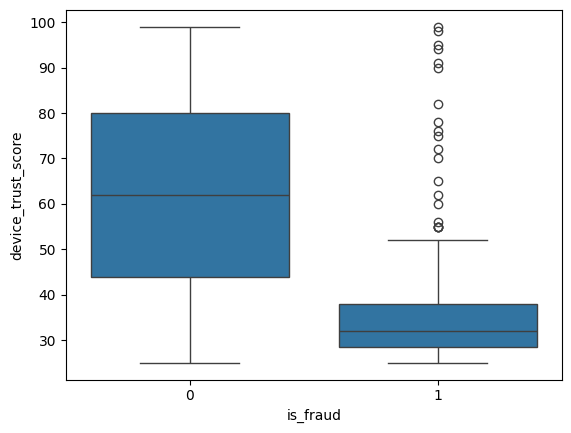

In [24]:
sns.boxplot(x='is_fraud', y='device_trust_score', data=Fraud_detection_df)


C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='is_fraud', ylabel='amount'>

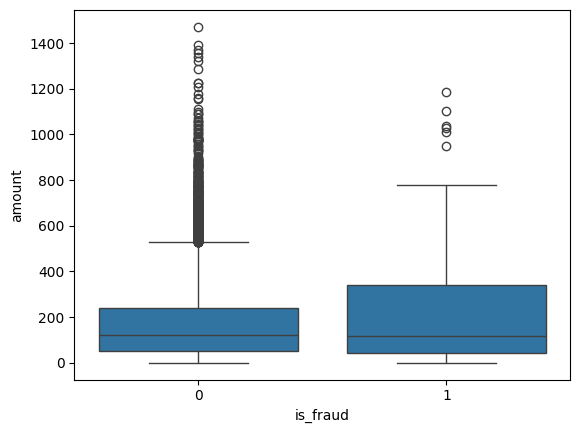

In [25]:
sns.boxplot(x='is_fraud', y='amount', data=Fraud_detection_df)


C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='is_fraud', ylabel='velocity_last_24h'>

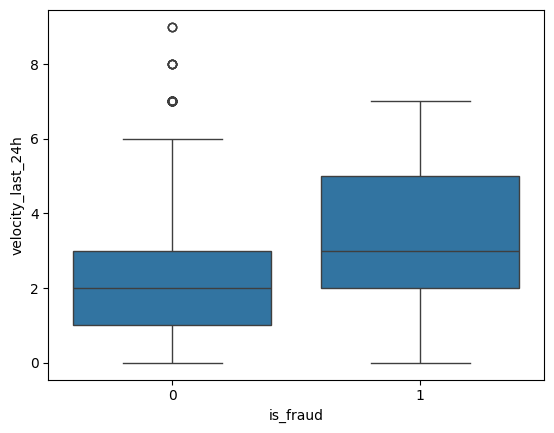

In [26]:
sns.boxplot(x='is_fraud', y='velocity_last_24h', data=Fraud_detection_df)


C:\Users\Parag\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='is_fraud', ylabel='device_trust_score'>

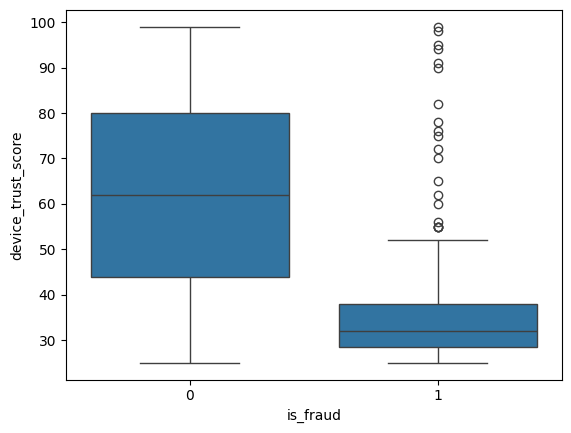

In [27]:
sns.boxplot(x='is_fraud', y='device_trust_score', data=Fraud_detection_df)


In [28]:
#Device trust score shows the strongest separation between fraud and non-fraud transactions. 
#Fraudulent transactions tend to have significantly lower trust scores. 
#Transaction velocity in the last 24 hours is also higher for fraud cases, indicating behavioral anomaly patterns.

In [29]:
df = Fraud_detection_df.copy()

df = df.drop(columns=['transaction_id'])

In [30]:
df.isnull().sum()

amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [31]:
df = pd.get_dummies(df, columns=['merchant_category'], drop_first=True,dtype=int)

In [32]:
df['is_night'] = df['transaction_hour'].apply(lambda x: 1 if x >= 0 and x <= 5 else 0)

In [33]:
df['high_velocity_flag'] = df['velocity_last_24h'].apply(lambda x: 1 if x > 4 else 0)

In [34]:
df['low_trust_flag'] = df['device_trust_score'].apply(lambda x: 1 if x < 40 else 0)

In [35]:
df.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,is_night,high_velocity_flag,low_trust_flag
0,84.47,22,0,0,66,3,40,0,1,0,0,0,0,0,0
1,541.82,3,1,0,87,1,64,0,0,0,0,1,1,0,0
2,237.01,17,0,0,49,1,61,0,0,0,1,0,0,0,0
3,164.33,4,0,1,72,3,34,0,0,0,1,0,1,0,0
4,30.53,15,0,0,79,0,44,0,0,1,0,0,0,0,0


In [36]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

In [37]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y):
     X_train,  X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
     y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()


In [38]:


scaler = StandardScaler()

num_cols = ['amount', 'transaction_hour', 'device_trust_score',
            'velocity_last_24h', 'cardholder_age']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [39]:
z_threshold = 3

X_train_z = X_train.copy()
X_test_z = X_test.copy()

for col in num_cols:
    mean = X_train[col].mean()
    std = X_train[col].std()
    
    X_test_z[col + "_z"] = (X_test[col] - mean) / std

In [40]:
z_cols = [col + "_z" for col in num_cols]

X_test_z['z_anomaly_flag'] = (X_test_z[z_cols].abs() > z_threshold).any(axis=1).astype(int)

In [41]:
print(confusion_matrix(y_test, X_test_z['z_anomaly_flag']))
print(classification_report(y_test, X_test_z['z_anomaly_flag']))

[[1915   55]
 [  30    0]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1970
           1       0.00      0.00      0.00        30

    accuracy                           0.96      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.97      0.96      0.96      2000



In [42]:
X_test_iqr = X_test.copy()
iqr_flags = []

for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    flag = ((X_test[col] < lower) | (X_test[col] > upper))
    iqr_flags.append(flag)

X_test_iqr['iqr_anomaly_flag'] = np.column_stack(iqr_flags).any(axis=1).astype(int)

In [43]:
print(confusion_matrix(y_test, X_test_iqr['iqr_anomaly_flag']))
print(classification_report(y_test, X_test_iqr['iqr_anomaly_flag']))

[[1861  109]
 [  29    1]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1970
           1       0.01      0.03      0.01        30

    accuracy                           0.93      2000
   macro avg       0.50      0.49      0.49      2000
weighted avg       0.97      0.93      0.95      2000



Z-score detection failed to capture fraudulent transactions, indicating that fraud in this dataset does not manifest as extreme univariate deviations. The IQR method showed minimal detection capability with high false positives. This suggests that fraud behavior is contextual and requires multivariate machine learning approaches.

## Isolation Forest — Contamination Tuning

Testing two contamination values to find the optimal fraud detection rate.
contamination represents the expected proportion of anomalies in the dataset.
Starting at 0.015 (matching ~1.5% fraud rate), then testing 0.030.

In [44]:
#Isolation Forest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.015,  # start near fraud rate (~1.5%)
    random_state=42
)

In [45]:
iso.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.015
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [46]:
iso_preds = iso.predict(X_test)

In [47]:
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

In [48]:
print(confusion_matrix(y_test, iso_preds))
print(classification_report(y_test, iso_preds))

[[1951   19]
 [  17   13]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1970
           1       0.41      0.43      0.42        30

    accuracy                           0.98      2000
   macro avg       0.70      0.71      0.71      2000
weighted avg       0.98      0.98      0.98      2000



### contamination=0.015
Recall of 0.43 — too conservative. Model misses too many frauds.
Increasing contamination to cast a wider net.

In [49]:
iso_1 = IsolationForest(
    n_estimators=200,
    contamination=0.030,  # start near fraud rate (~1.5%)
    random_state=42
)

In [50]:
iso_1.fit(X_train)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [51]:
iso_preds_1 = iso_1.predict(X_test)

In [52]:
iso_preds_1 = [1 if x == -1 else 0 for x in iso_preds_1]

In [53]:
print(confusion_matrix(y_test, iso_preds_1))
print(classification_report(y_test, iso_preds_1))

[[1932   38]
 [   8   22]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.37      0.73      0.49        30

    accuracy                           0.98      2000
   macro avg       0.68      0.86      0.74      2000
weighted avg       0.99      0.98      0.98      2000



### contamination=0.030
Recall improves to 0.73 — significantly better fraud capture.
Selected contamination=0.030 for the final Isolation Forest model.

In [54]:
# One-Class SVM

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_normal = X_train_scaled[y_train == 0]

In [57]:
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.015)
ocsvm.fit(X_train_normal)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.015
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [58]:
svm_preds = ocsvm.predict(X_test_scaled)
svm_preds = [1 if x == -1 else 0 for x in svm_preds]

In [59]:
#svm_preds

In [60]:
print("One-Class SVM Results")
print(confusion_matrix(y_test, svm_preds))
print(classification_report(y_test, svm_preds))

One-Class SVM Results
[[1921   49]
 [  10   20]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1970
           1       0.29      0.67      0.40        30

    accuracy                           0.97      2000
   macro avg       0.64      0.82      0.69      2000
weighted avg       0.98      0.97      0.98      2000



In [61]:
# LOF

In [62]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.015, novelty=True)
lof.fit(X_train)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.015
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [63]:
lof_preds = lof.predict(X_test)
lof_preds = [1 if x == -1 else 0 for x in lof_preds]

C:\Users\Parag\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [64]:
print("LOF Results")
print(confusion_matrix(y_test, lof_preds))
print(classification_report(y_test, lof_preds))

LOF Results
[[1947   23]
 [  27    3]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1970
           1       0.12      0.10      0.11        30

    accuracy                           0.97      2000
   macro avg       0.55      0.54      0.55      2000
weighted avg       0.97      0.97      0.97      2000



## LOF — Results & Analysis

LOF achieved the lowest fraud recall (0.10) among all unsupervised models.

**Why LOF underperforms here:**
- LOF relies on local density comparisons between neighbors
- With highly imbalanced data (1.5% fraud), fraudulent points 
  are too sparse for meaningful local density estimation
- LOF works best when anomalies form small tight clusters — 
  fraud in this dataset is scattered across feature space

**Decision:** LOF eliminated. Isolation Forest (tuned) and 
One-Class SVM carry forward to the ensemble comparison.

In [65]:
models = {
    "Isolation Forest": iso_preds_1,      
    "One-Class SVM": svm_preds,
    "LOF": lof_preds
}

results = []

for name, preds in models.items():
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, precision, recall, f1])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Fraud Precision", "Fraud Recall", "Fraud F1"]
)

print(comparison_df)

              Model  Fraud Precision  Fraud Recall  Fraud F1
0  Isolation Forest         0.366667      0.733333  0.488889
1     One-Class SVM         0.289855      0.666667  0.404040
2               LOF         0.115385      0.100000  0.107143


Among unsupervised models, Isolation Forest (contamination=0.030) 
achieved the highest fraud recall (0.73) and F1 (0.49), outperforming 
One-Class SVM (recall: 0.67) and LOF (recall: 0.10).
Isolation Forest is selected for the final hybrid ensemble.

RandomForest Classifier

In [66]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.60      0.75        30

    accuracy                           0.99      2000
   macro avg       1.00      0.80      0.87      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9999492385786802


In [67]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

C:\Users\Parag\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:52:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 1.0


In [68]:
y_proba = xgb.predict_proba(X_test)[:, 1]   # or rf

In [69]:
threshold = 0.30   # start lower than 0.5

y_pred_custom = (y_proba > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_custom)
print(cm)

[[1970    0]
 [   0   30]]


In [70]:
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)

print("Precision:", precision)
print("Recall:", recall)
print("False Positive Rate:", fpr)

Precision: 1.0
Recall: 1.0
False Positive Rate: 0.0


In [71]:
for t in np.arange(0.1, 0.9, 0.05):
    y_pred_temp = (y_proba > t).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    TN, FP, FN, TP = cm.ravel()

    recall = TP / (TP + FN)
    fpr = FP / (FP + TN)

    print(f"Threshold: {t:.2f} | Recall: {recall:.3f} | FPR: {fpr:.3f}")

Threshold: 0.10 | Recall: 1.000 | FPR: 0.000
Threshold: 0.15 | Recall: 1.000 | FPR: 0.000
Threshold: 0.20 | Recall: 1.000 | FPR: 0.000
Threshold: 0.25 | Recall: 1.000 | FPR: 0.000
Threshold: 0.30 | Recall: 1.000 | FPR: 0.000
Threshold: 0.35 | Recall: 1.000 | FPR: 0.000
Threshold: 0.40 | Recall: 1.000 | FPR: 0.000
Threshold: 0.45 | Recall: 1.000 | FPR: 0.000
Threshold: 0.50 | Recall: 1.000 | FPR: 0.000
Threshold: 0.55 | Recall: 1.000 | FPR: 0.000
Threshold: 0.60 | Recall: 1.000 | FPR: 0.000
Threshold: 0.65 | Recall: 1.000 | FPR: 0.000
Threshold: 0.70 | Recall: 1.000 | FPR: 0.000
Threshold: 0.75 | Recall: 1.000 | FPR: 0.000
Threshold: 0.80 | Recall: 1.000 | FPR: 0.000
Threshold: 0.85 | Recall: 1.000 | FPR: 0.000


In [72]:
print("is_fraud" in X_train.columns)

False


In [73]:
corr = df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)
print(corr.head(10))

is_fraud                     1.000000
low_trust_flag               0.191216
foreign_transaction          0.185597
high_velocity_flag           0.175762
location_mismatch            0.173009
is_night                     0.165626
velocity_last_24h            0.103413
amount                       0.028404
merchant_category_Grocery    0.019987
merchant_category_Food       0.006845
Name: is_fraud, dtype: float64


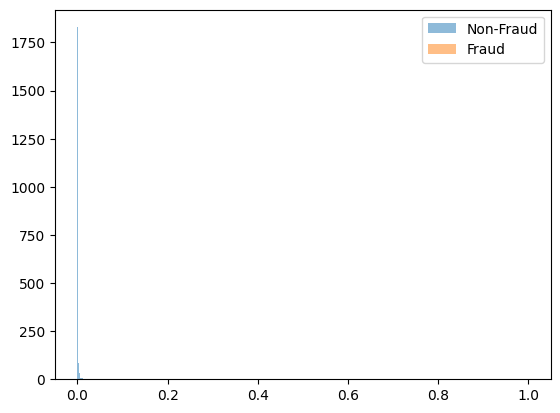

In [74]:


plt.hist(y_proba[y_test==0], bins=30, alpha=0.5, label="Non-Fraud")
plt.hist(y_proba[y_test==1], bins=30, alpha=0.5, label="Fraud")
plt.legend()
plt.show()

In [75]:
print("Non-Fraud min/max:", 
      y_proba[y_test==0].min(), 
      y_proba[y_test==0].max())

print("Fraud min/max:", 
      y_proba[y_test==1].min(), 
      y_proba[y_test==1].max())

Non-Fraud min/max: 1.1331435e-05 0.068269014
Fraud min/max: 0.994968 0.9999263


In [76]:
xgb_score = xgb.predict_proba(X_test)[:, 1]

In [77]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso.fit(X_train)

iso_raw = iso.decision_function(X_test)

In [78]:
iso_score = -iso_raw

In [79]:
scaler = MinMaxScaler()
iso_score = scaler.fit_transform(iso_score.reshape(-1,1)).flatten()

In [80]:
print(iso_score.min(), iso_score.max())

0.0 1.0


In [81]:
stat_score = (
    0.25 * X_test["foreign_transaction"] +
    0.25 * X_test["location_mismatch"] +
    0.25 * (X_test["velocity_last_24h"] > 3).astype(int) +
    0.25 * (X_test["device_trust_score"] < 40).astype(int)
)

In [82]:
stat_score = stat_score / stat_score.max()

In [83]:
final_score = (
    0.3 * stat_score +
    0.4 * iso_score +
    0.3 * xgb_score
)

In [84]:
print(final_score.min(), final_score.max())

0.10000339943085236 0.991485649397706


In [85]:
risk_level = np.where(
    final_score < 0.3, "Low",
    np.where(final_score < 0.6, "Medium", "High")
)

In [86]:
risk_df = X_test.copy()

risk_df["xgb_score"] = xgb_score
risk_df["iso_score"] = iso_score
risk_df["stat_score"] = stat_score
risk_df["final_score"] = final_score
risk_df["risk_level"] = risk_level
risk_df["actual_label"] = y_test.values

In [87]:
print(risk_df["risk_level"].value_counts())

risk_level
Low       1373
Medium     585
High        42
Name: count, dtype: int64


In [88]:
pd.crosstab(risk_df["risk_level"], risk_df["actual_label"])

actual_label,0,1
risk_level,,
High,12,30
Low,1373,0
Medium,585,0


In [89]:
high_df = risk_df[risk_df["risk_level"] == "High"]

precision_high = high_df["actual_label"].sum() / len(high_df)
print("High Bucket Precision:", precision_high)

High Bucket Precision: 0.7142857142857143


Business Impact Simulation

In [90]:
fraud_loss = 500      # ₹ lost per missed fraud
review_cost = 50      # ₹ cost per manual review

In [91]:
# Fraud caught
fraud_caught = risk_df[(risk_df["risk_level"] == "High") & 
                       (risk_df["actual_label"] == 1)].shape[0]

# Fraud missed
fraud_missed = risk_df[(risk_df["risk_level"] != "High") & 
                       (risk_df["actual_label"] == 1)].shape[0]

# Legit flagged (false positives)
false_positives = risk_df[(risk_df["risk_level"] == "High") & 
                          (risk_df["actual_label"] == 0)].shape[0]

total_loss = fraud_missed * fraud_loss + false_positives * review_cost

print("Fraud caught:", fraud_caught)
print("Fraud missed:", fraud_missed)
print("False positives:", false_positives)
print("Total business cost:", total_loss)

Fraud caught: 30
Fraud missed: 0
False positives: 12
Total business cost: 600


In [92]:
fraud_caught_alt = risk_df[(risk_df["risk_level"] != "Low") & 
                           (risk_df["actual_label"] == 1)].shape[0]

fraud_missed_alt = risk_df[(risk_df["risk_level"] == "Low") & 
                           (risk_df["actual_label"] == 1)].shape[0]

false_positives_alt = risk_df[(risk_df["risk_level"] != "Low") & 
                              (risk_df["actual_label"] == 0)].shape[0]

total_loss_alt = fraud_missed_alt * fraud_loss + false_positives_alt * review_cost

print("Alternative Total Cost:", total_loss_alt)

Alternative Total Cost: 29850


In [93]:
# Alert Generation

In [94]:
# Filter high risk transactions
alerts_df = risk_df[risk_df["risk_level"] == "High"].copy()

In [95]:
alerts_df["alert_id"] = [str(uuid.uuid4())[:8] for _ in range(len(alerts_df))]

In [96]:
alerts_df["transaction_id"] = alerts_df.index

In [97]:
alerts_df["risk_score"] = alerts_df["final_score"]

In [98]:
def generate_reason(row):
    reasons = []
    
    if row["foreign_transaction"] == 1:
        reasons.append("Foreign Transaction")
    if row["location_mismatch"] == 1:
        reasons.append("Location Mismatch")
    if row["velocity_last_24h"] > 3:
        reasons.append("High Transaction Velocity")
    if row["device_trust_score"] < 40:
        reasons.append("Low Device Trust")
        
    return ", ".join(reasons)

alerts_df["reason"] = alerts_df.apply(generate_reason, axis=1)

In [99]:
alerts_df["status"] = "Open"

In [100]:
alerts_df["created_at"] = datetime.now()

In [101]:
alerts_df = alerts_df[
    ["alert_id",
     "transaction_id",
     "risk_score",
     "risk_level",
     "reason",
     "status",
     "created_at"]
]

In [102]:
alerts_df.head()

,alert_id,transaction_id,risk_score,risk_level,reason,status,created_at
7656,0f7f8e66,7656,0.954627,High,"Foreign Transaction, Location Mismatch, Low De...",Open,2026-06-24 16:52:15.729073
6916,3828d860,6916,0.607939,High,"Foreign Transaction, Location Mismatch, Low De...",Open,2026-06-24 16:52:15.729073
8121,b07a4065,8121,0.851867,High,"Location Mismatch, Low Device Trust",Open,2026-06-24 16:52:15.729073
7166,68f5a89c,7166,0.601661,High,"Foreign Transaction, Location Mismatch, Low De...",Open,2026-06-24 16:52:15.729073
6157,961889b3,6157,0.734760,High,Low Device Trust,Open,2026-06-24 16:52:15.729073


In [103]:
alerts_df.to_csv("outputs/alerts_generated.csv", index=False)

In [104]:

risk_df = pd.DataFrame({
    "transaction_id": X_test.index,
    "actual_label": y_test.values
})

alerts_df = pd.read_csv("outputs/alerts_generated.csv")
alerts_df["created_at"] = pd.to_datetime(alerts_df["created_at"])


alerts_df = alerts_df.merge(
    risk_df,
    on="transaction_id",
    how="left"
)


alerts_df["assigned_to"] = None
alerts_df["reviewed_at"] = None
alerts_df["resolution"] = None
alerts_df["comments"] = None
alerts_df["resolved_at"] = None


analysts = ["Analyst_A", "Analyst_B", "Analyst_C"]

alerts_df["assigned_to"] = np.random.choice(analysts, size=len(alerts_df))
alerts_df["status"] = "Under Review"
alerts_df["reviewed_at"] = pd.Timestamp.now()


alerts_df["resolution"] = np.where(
    alerts_df["actual_label"] == 1,
    "Fraud Confirmed",
    "False Positive"
)

alerts_df["status"] = "Closed"
alerts_df["resolved_at"] = pd.Timestamp.now()


alerts_df["comments"] = np.where(
    alerts_df["resolution"] == "Fraud Confirmed",
    "Confirmed suspicious pattern. Card blocked.",
    "Transaction verified with customer. No fraud detected."
)


alerts_df["resolution_time_minutes"] = (
    alerts_df["resolved_at"] - alerts_df["reviewed_at"]
).dt.total_seconds() / 60


print("Resolution Breakdown:")
print(alerts_df["resolution"].value_counts())

confirmation_rate = (
    alerts_df["resolution"] == "Fraud Confirmed"
).mean()

false_positive_rate = (
    alerts_df["resolution"] == "False Positive"
).mean()

print("\nFraud Confirmation Rate:", round(confirmation_rate, 3))
print("False Positive Rate:", round(false_positive_rate, 3))


alerts_df.to_csv("outputs/alerts_investigated.csv", index=False)

print("\nInvestigation workflow completed successfully.")

Resolution Breakdown:
resolution
Fraud Confirmed    30
False Positive     12
Name: count, dtype: int64

Fraud Confirmation Rate: 0.714
False Positive Rate: 0.286

Investigation workflow completed successfully.


In [105]:
false_positive_df = alerts_df[
    alerts_df["resolution"] == "False Positive"
]

print("Number of False Positives:", len(false_positive_df))
false_positive_df.head()

Number of False Positives: 12


,alert_id,transaction_id,risk_score,risk_level,reason,status,created_at,actual_label,assigned_to,reviewed_at,resolution,comments,resolved_at,resolution_time_minutes
1,3828d860,6916,0.607939,High,"Foreign Transaction, Location Mismatch, Low De...",Closed,2026-06-24 16:52:15.729073,0,Analyst_C,2026-06-24 16:52:17.280246,False Positive,Transaction verified with customer. No fraud d...,2026-06-24 16:52:17.281246,0.000017
3,68f5a89c,7166,0.601661,High,"Foreign Transaction, Location Mismatch, Low De...",Closed,2026-06-24 16:52:15.729073,0,Analyst_B,2026-06-24 16:52:17.280246,False Positive,Transaction verified with customer. No fraud d...,2026-06-24 16:52:17.281246,0.000017
5,2c5c26ec,6394,0.673841,High,"Foreign Transaction, Location Mismatch, Low De...",Closed,2026-06-24 16:52:15.729073,0,Analyst_C,2026-06-24 16:52:17.280246,False Positive,Transaction verified with customer. No fraud d...,2026-06-24 16:52:17.281246,0.000017
6,2013a666,3148,0.612172,High,"Foreign Transaction, Location Mismatch, Low De...",Closed,2026-06-24 16:52:15.729073,0,Analyst_A,2026-06-24 16:52:17.280246,False Positive,Transaction verified with customer. No fraud d...,2026-06-24 16:52:17.281246,0.000017
8,a2d9392e,67,0.614736,High,"Foreign Transaction, Location Mismatch, Low De...",Closed,2026-06-24 16:52:15.729073,0,Analyst_B,2026-06-24 16:52:17.280246,False Positive,Transaction verified with customer. No fraud d...,2026-06-24 16:52:17.281246,0.000017


In [106]:
analysis_df = alerts_df.merge(
    X_test.reset_index(),
    left_on="transaction_id",
    right_on="index",
    how="left"
)

analysis_df.drop(columns=["index"], inplace=True)

In [107]:
fp_df = analysis_df[analysis_df["resolution"] == "False Positive"]
fraud_df = analysis_df[analysis_df["resolution"] == "Fraud Confirmed"]

In [108]:
comparison = pd.DataFrame({
    "False_Positive_Mean": fp_df.mean(numeric_only=True),
    "Fraud_Mean": fraud_df.mean(numeric_only=True)
})

comparison

,False_Positive_Mean,Fraud_Mean
transaction_id,5003.500000,4746.966667
risk_score,0.626795,0.858777
actual_label,0.000000,1.000000
resolution_time_minutes,0.000017,0.000017
amount,0.584825,0.053816
transaction_hour,-0.121248,-1.251379
foreign_transaction,0.750000,0.600000
location_mismatch,1.000000,0.533333
device_trust_score,0.593528,-1.172260
velocity_last_24h,0.457774,0.619911


In [109]:
importance = xgb.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
4,device_trust_score,0.347804
1,transaction_hour,0.234040
5,velocity_last_24h,0.160239
2,foreign_transaction,0.105659
0,amount,0.075266
3,location_mismatch,0.069971
10,merchant_category_Travel,0.005075
6,cardholder_age,0.000949
9,merchant_category_Grocery,0.000488
8,merchant_category_Food,0.000425


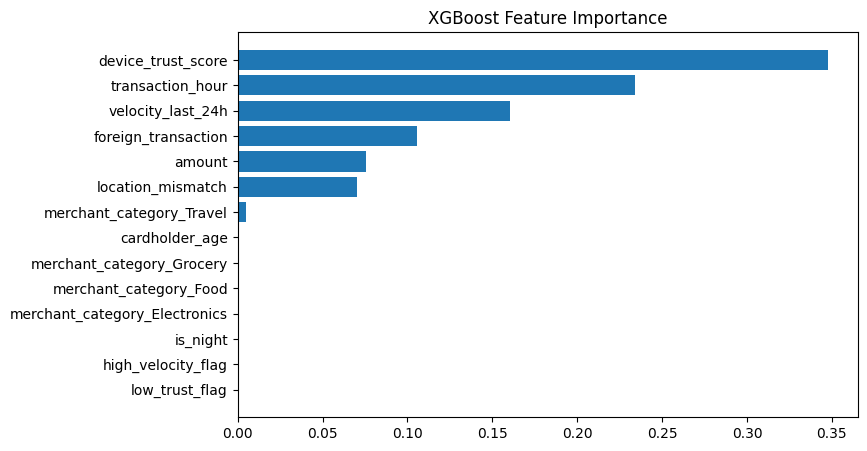

In [110]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

In [111]:
new_threshold = 0.85

alerts_df["new_prediction"] = np.where(
    alerts_df["risk_score"] >= new_threshold,
    1,
    0
)



cm = confusion_matrix(
    alerts_df["actual_label"],
    alerts_df["new_prediction"]
)

cm

array([[12,  0],
       [16, 14]], dtype=int64)

False positives were primarily driven by foreign transactions combined with location mismatch. However, device trust score and transaction velocity were not significantly abnormal in these cases. This suggests the model may be over-sensitive to cross-border behavioral patterns.

In [112]:
fp_df[[
    "device_trust_score",
    "velocity_last_24h",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch"
]].describe()

,device_trust_score,velocity_last_24h,transaction_hour,foreign_transaction,location_mismatch
count,12.000000,12.000000,12.000000,12.000000,12.0
mean,0.593528,0.457774,-0.121248,0.750000,1.0
std,0.795372,1.736121,0.908408,0.452267,0.0
min,-0.837249,-1.395211,-1.097161,0.000000,1.0
25%,0.256191,-0.700342,-0.952581,0.750000,1.0
50%,0.744749,-0.005472,-0.301973,1.000000,1.0
75%,1.210042,0.689398,0.601650,1.000000,1.0
max,1.582277,3.468876,1.360693,1.000000,1.0


In [113]:
mid_threshold = 0.75

alerts_df["mid_prediction"] = np.where(
    alerts_df["risk_score"] >= mid_threshold,
    1,
    0
)



cm_mid = confusion_matrix(
    alerts_df["actual_label"],
    alerts_df["mid_prediction"]
)

cm_mid

array([[12,  0],
       [ 1, 29]], dtype=int64)

Threshold sensitivity analysis showed that increasing risk threshold to 0.75 reduced false positives to zero while maintaining a fraud detection rate of 96.7%. This represents a significantly improved operational balance compared to both lower and higher thresholds.

In [114]:
threshold = 0.75

alerts_df["monitor_prediction"] = np.where(
    alerts_df["risk_score"] >= threshold,
    1,
    0
)

# Confusion Matrix
cm = confusion_matrix(
    alerts_df["actual_label"],
    alerts_df["monitor_prediction"]
)

TN, FP, FN, TP = cm.ravel()

# Metrics
detection_rate = TP / (TP + FN)
false_positive_rate = FP / (FP + TN)
alert_volume = alerts_df["monitor_prediction"].sum()

print("Detection Rate:", round(detection_rate, 3))
print("False Positive Rate:", round(false_positive_rate, 3))
print("Alert Volume:", alert_volume)

Detection Rate: 0.967
False Positive Rate: 0.0
Alert Volume: 29


With threshold set at 0.75, the monitoring dashboard shows a fraud detection rate of 96.7% while maintaining a 0% false positive rate. Alert volume remains operationally manageable at 29 cases.

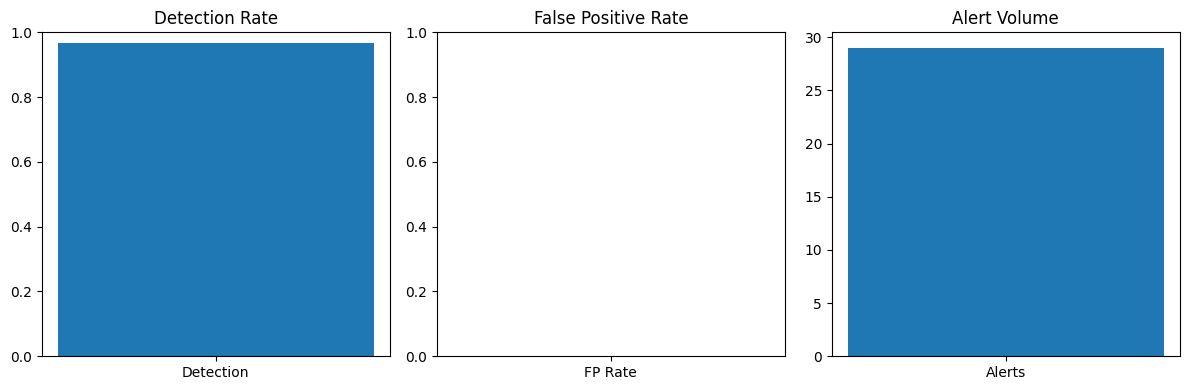

In [115]:
plt.figure(figsize=(12,4))

# Detection Rate
plt.subplot(1,3,1)
plt.bar(["Detection"], [detection_rate])
plt.ylim(0,1)
plt.title("Detection Rate")

# False Positive Rate
plt.subplot(1,3,2)
plt.bar(["FP Rate"], [false_positive_rate])
plt.ylim(0,1)
plt.title("False Positive Rate")

# Alert Volume
plt.subplot(1,3,3)
plt.bar(["Alerts"], [alert_volume])
plt.title("Alert Volume")

plt.tight_layout()
plt.show()

In [116]:
# Get predicted probabilities
y_probs = rf.predict_proba(X_test)[:, 1]

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

# Best threshold based on F1
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.315
Best F1 Score: 0.9830503476015181


In [117]:
y_pred_optimized = (y_probs >= best_threshold).astype(int)

In [118]:
FN_cost = 10000
FP_cost = 500

costs = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    
    TP = np.sum((preds == 1) & (y_test == 1))
    FP = np.sum((preds == 1) & (y_test == 0))
    FN = np.sum((preds == 0) & (y_test == 1))
    
    total_cost = (FN * FN_cost) + (FP * FP_cost)
    costs.append(total_cost)

optimal_index = np.argmin(costs)
optimal_threshold_cost = thresholds[optimal_index]

print("Cost-Optimized Threshold:", optimal_threshold_cost)

Cost-Optimized Threshold: 0.155


In [119]:
Fraud_detection_df["fraud_probability"] = rf.predict_proba(X)[:, 1]

# Sort by risk
Fraud_detection_df = Fraud_detection_df.sort_values(
    by="fraud_probability", ascending=False
)

# Select top 100 highest risk alerts
daily_capacity = 100
alerts_today = Fraud_detection_df.head(daily_capacity)

alerts_today.to_csv("outputs/prioritized_alerts.csv", index=False)

In [120]:
scaler = MinMaxScaler()

Fraud_detection_df["ml_score_scaled"] = scaler.fit_transform(
    Fraud_detection_df[["fraud_probability"]]
)

Fraud_detection_df["composite_score"] = Fraud_detection_df["ml_score_scaled"]

Fraud_detection_df = Fraud_detection_df.sort_values(
    by="composite_score", ascending=False
)

In [121]:
Fraud_detection_df = Fraud_detection_df.sort_values(
    by="composite_score", ascending=False
)

In [122]:
cm = confusion_matrix(y_test, y_pred_optimized)

TN, FP, FN, TP = cm.ravel()

print("False Positives:", FP)
print("False Negative:", FN)
print("Precision:", TP / (TP + FP))
print("Recall:", TP / (TP + FN))

False Positives: 0
False Negative: 1
Precision: 1.0
Recall: 0.9666666666666667


In [123]:
false_positives = X_test[(y_pred_optimized == 1) & (y_test == 0)]
false_positives.to_csv("outputs/false_positive_cases.csv", index=False)